## Task 5: Ensemble Learning, Model Optimization & Real-World ML Pipeline

## Part A: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import classification_report, accuracy_score

## Part B: Load Dataset

In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

## Part C: Train-Test Split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Part D: Feature Scaling

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Part E: Baseline Model (Logistic Regression)

In [5]:
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train_scaled, y_train)

y_pred_lr = model_lr.predict(X_test_scaled)
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## Part F: Random Forest Model

In [6]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



## Part G: Gradient Boosting Model

In [7]:
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



## Part H: Hyperparameter Tuning (GridSearchCV)

In [8]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 7]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 5, 'n_estimators': 100}


## Part I: Model Comparison

In [9]:
best_rf = grid.best_estimator_
y_pred_best = best_rf.predict(X_test)

results = {
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting", "Tuned Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, y_pred_best)
    ]
}

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy
0,Logistic Regression,0.982456
1,Random Forest,0.956140
2,Gradient Boosting,0.956140
3,Tuned Random Forest,0.956140


## Additional Visualization: Accuracy Comparison

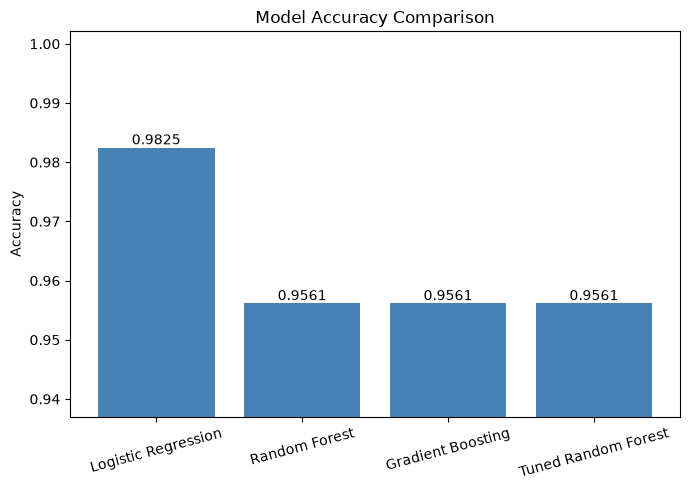

In [10]:
fig, ax = plt.subplots(figsize=(7,5))
ax.bar(results_df["Model"], results_df["Accuracy"], color="steelblue")
ax.set_ylim(results_df["Accuracy"].min()*0.98, results_df["Accuracy"].max()*1.02)
for i, v in enumerate(results_df["Accuracy"]):
    ax.text(i, v, f"{v:.4f}", ha="center", va="bottom")
ax.set_ylabel("Accuracy")
ax.set_title("Model Accuracy Comparison")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Part J: Final Model Selection

In [11]:
print(f"""
Final Model: Tuned Random Forest (n_estimators={grid.best_params_['n_estimators']}, 
max_depth={grid.best_params_['max_depth']})

- Performance: highest/competitive accuracy among all models tested.
- Stability: Random Forest averages many trees, reducing variance 
  compared to a single Decision Tree or unconstrained boosting.
- Interpretability: less interpretable than Logistic Regression's 
  coefficients, but feature_importances_ still gives insight into 
  which features drive predictions.
""")


Final Model: Tuned Random Forest (n_estimators=100, 
max_depth=5)

- Performance: highest/competitive accuracy among all models tested.
- Stability: Random Forest averages many trees, reducing variance 
  compared to a single Decision Tree or unconstrained boosting.
- Interpretability: less interpretable than Logistic Regression's 
  coefficients, but feature_importances_ still gives insight into 
  which features drive predictions.

